# Airline passenger satisfaction

The aim is to predict whether a passenger is satisfied with their flight.

This dataset comes from a passenger satisfaction survey. Each row is one passenger, and the target is binary: satisfied or neutral/dissatisfied. The features include demographics (age, travel type), flight details (distance, delays), and service ratings (wifi, food, boarding, etc).

Our goal here is to understand the data, clean it up, engineer useful features, and save processed train/test splits for the classification notebook.

In [2]:
# standard imports for data exploration and preprocessing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid", palette="colorblind")
pd.set_option("display.max_rows", 80)
np.random.seed(42)

## Loading the data

In [3]:
# load raw data, audit columns, check for duplicates and missing values
df = pd.read_csv("../datasets/airline_passenger_satisfaction.csv")
df.columns = df.columns.str.strip()
print("Shape:", df.shape)
display(df.head())
audit = pd.DataFrame({"dtype": df.dtypes.astype(str), "missing": df.isna().sum(), "unique": df.nunique()})
display(audit)
print("Exact duplicates:", df.duplicated().sum())
display(df["satisfaction"].describe())

Shape: (103904, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


,dtype,missing,unique
Unnamed: 0,int64,0,103904
id,int64,0,103904
Gender,str,0,2
Customer Type,str,0,2
Age,int64,0,75
Type of Travel,str,0,2
Class,str,0,3
Flight Distance,int64,0,3802
Inflight wifi service,int64,0,6
Departure/Arrival time convenient,int64,0,6


Exact duplicates: 0


count                      103904
unique                          2
top       neutral or dissatisfied
freq                        58879
Name: satisfaction, dtype: object

There are 103,904 passengers and 25 columns. Arrival delay has 310 missing values. The row index and passenger ID do not describe the flight, so both are left out.

In [4]:
# encode target, drop ID columns, create stratified 80/20 split
print("Repeated passenger IDs:", df["id"].duplicated().sum())
df = df.drop_duplicates(subset="id").copy()
x = df.drop(columns=["Unnamed: 0", "id", "satisfaction"])
y = df["satisfaction"].map({"neutral or dissatisfied": 0, "satisfied": 1})
assert y.notna().all()
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

Repeated passenger IDs: 0


The target is 1 for satisfied and 0 for neutral or dissatisfied. The 80:20 split is stratified to keep the same class balance in both sets.

Stratified splitting makes sure both train and test sets have the same ~57/43 class ratio. This is important because if the test set happened to get more of one class, our accuracy numbers would be misleading.

In [5]:
# quick summary stats for the train and test splits
print("Training rows:", len(x_train), "Test rows:", len(x_test))
display(pd.DataFrame({"train": y_train.describe(), "test": y_test.describe()}))
data = x_train.copy()
data[y.name] = y_train

Training rows: 83123 Test rows: 20781


,train,test
count,83123.000000,20781.000000
mean,0.433334,0.433329
std,0.495539,0.495547
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,1.000000,1.000000
max,1.000000,1.000000


## Distributions

The following plots use the training set.

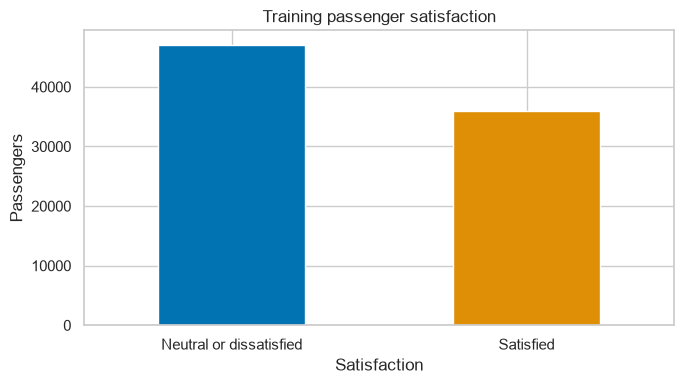

Neutral or dissatisfied    56.67
Satisfied                  43.33
Name: Percent, dtype: float64

In [6]:
# bar chart of satisfaction class balance
counts = y_train.value_counts().sort_index()
counts.index = ["Neutral or dissatisfied", "Satisfied"]
counts.plot.bar(figsize=(7, 4), color=sns.color_palette("colorblind")[:2], rot=0)
plt.title("Training passenger satisfaction")
plt.xlabel("Satisfaction")
plt.ylabel("Passengers")
plt.tight_layout()
plt.show()
display((counts / counts.sum() * 100).round(2).rename("Percent"))

About 57% of passengers are neutral or dissatisfied and 43% are satisfied. This is a moderate imbalance, so accuracy will be compared with weighted F1 and ROC-AUC.

A 57/43 split isn't terrible, but it's enough to make accuracy slightly misleading on its own. That's why we'll track weighted F1 and ROC-AUC alongside accuracy in the classification notebook. These metrics account for the class sizes.

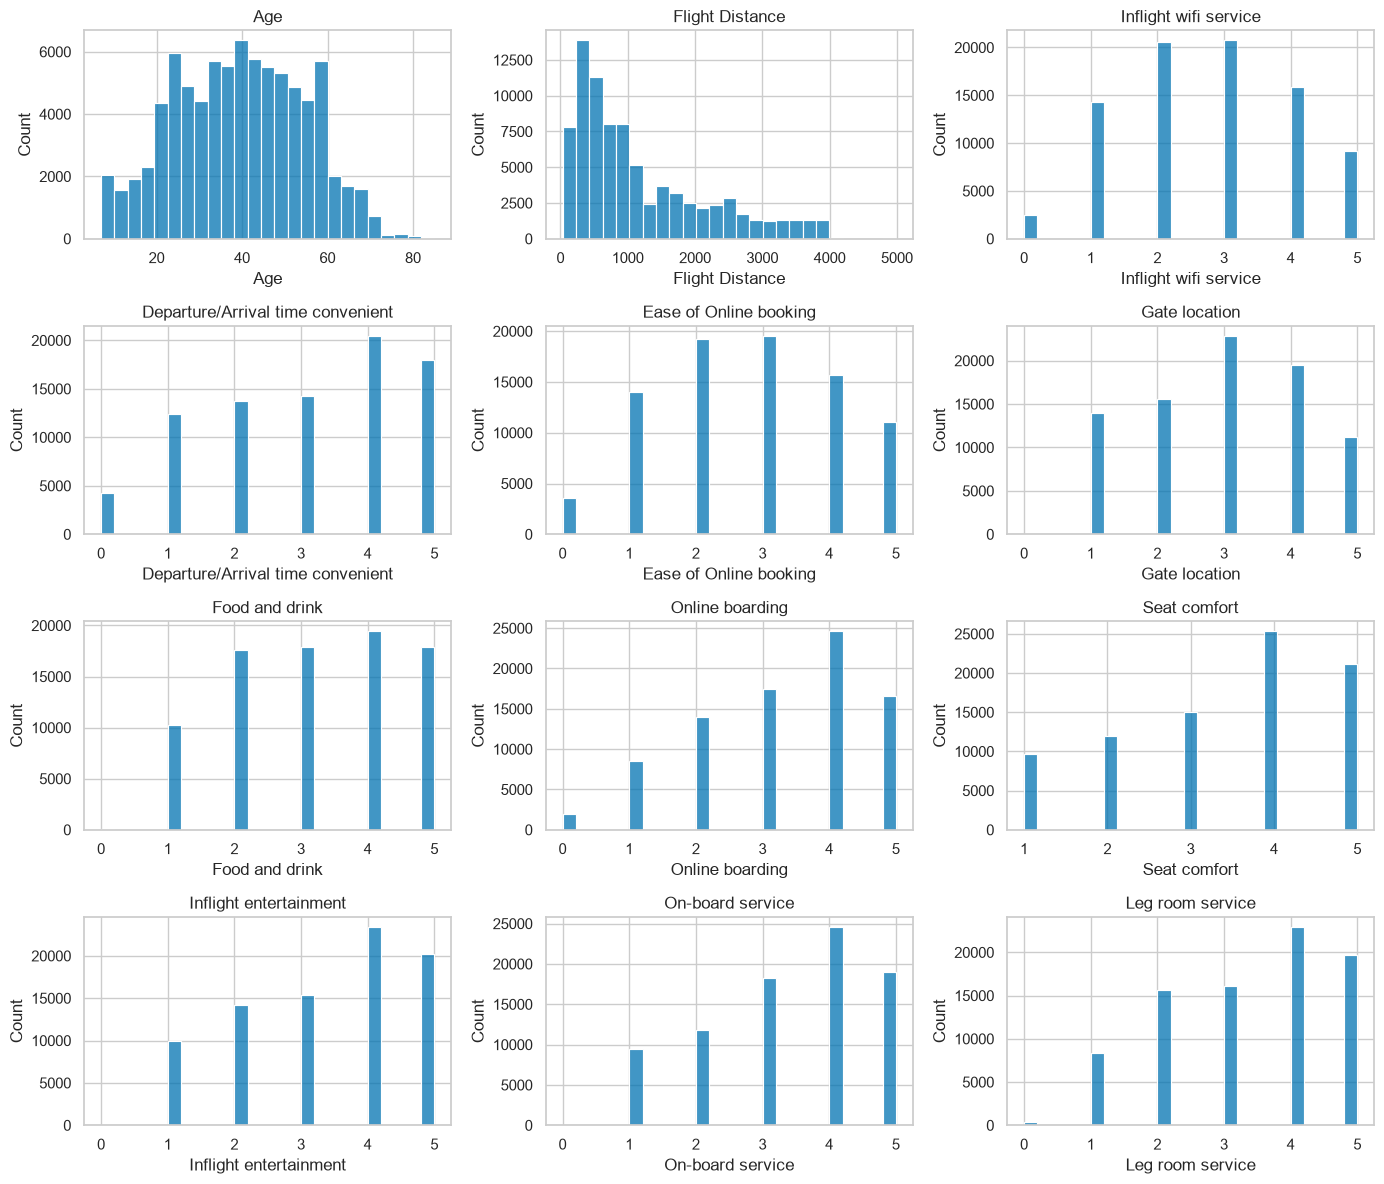

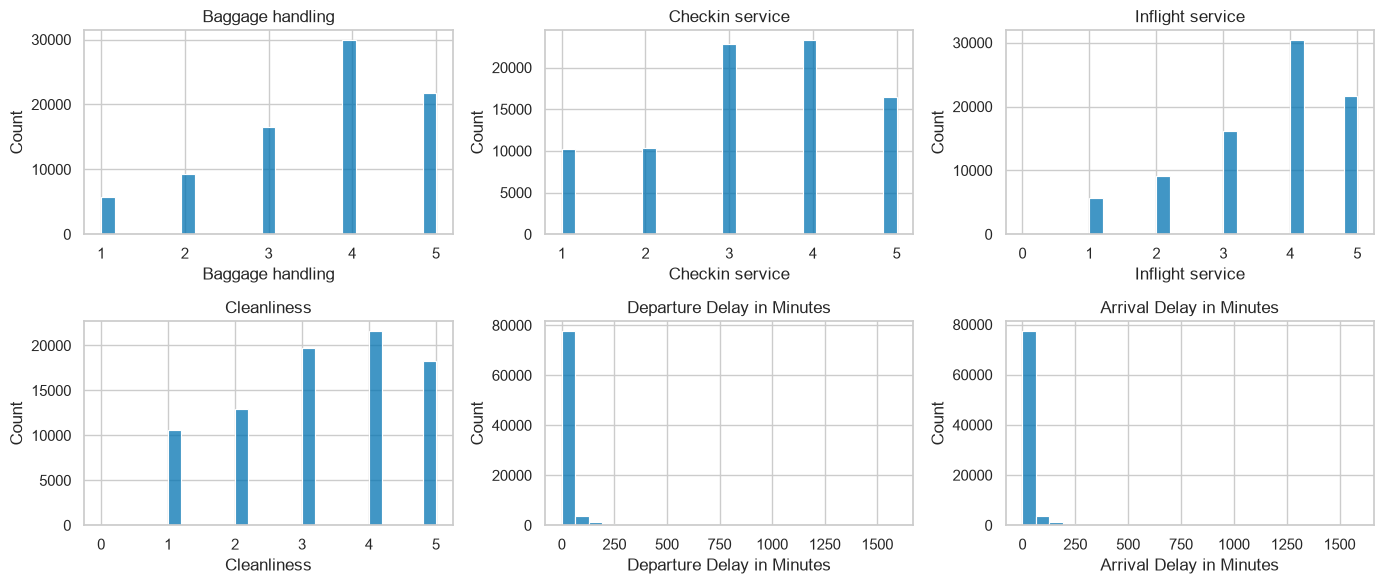

In [7]:
num = x_train.select_dtypes(include="number").columns.tolist()
for start in range(0, len(num), 12):
    cols = num[start:start + 12]
    fig, axes = plt.subplots(int(np.ceil(len(cols) / 3)), 3, figsize=(14, 3 * int(np.ceil(len(cols) / 3))))
    for ax, col in zip(axes.ravel(), cols):
        sns.histplot(x_train[col], bins=25, ax=ax)
        ax.set(title=col, xlabel=col, ylabel="Count")
    for ax in axes.ravel()[len(cols):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

Service ratings are discrete values from 0 to 5. Distances and delays are right-skewed. Zero ratings are kept because they may represent a service that was not applicable.

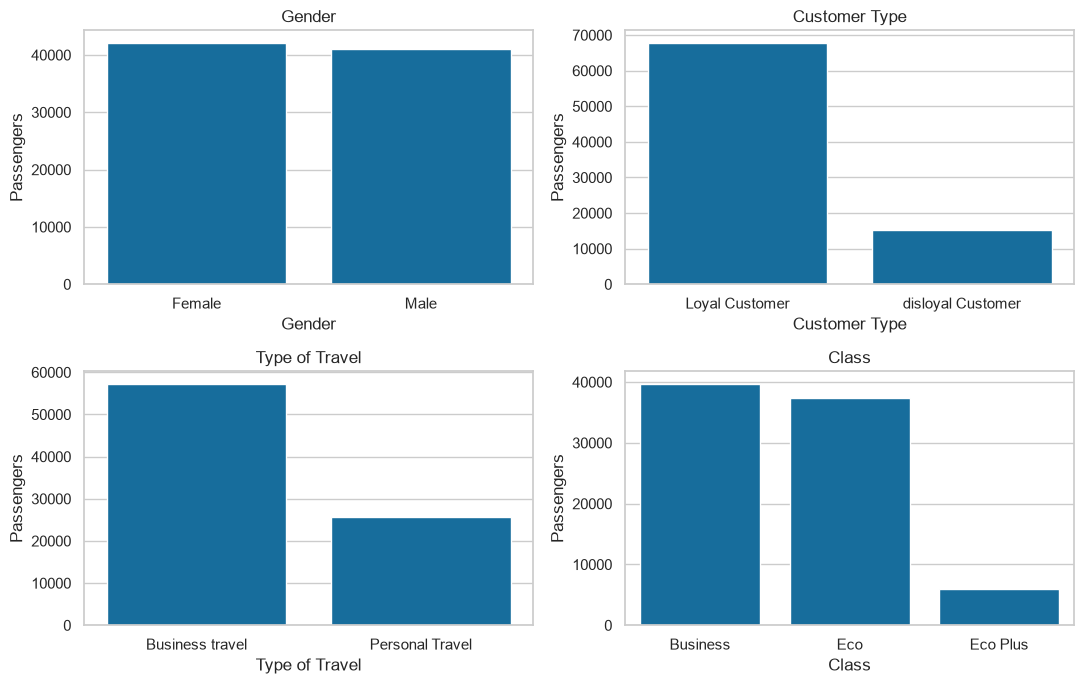

In [8]:
cat = x_train.select_dtypes(include=["str", "object", "category"]).columns.tolist()
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.ravel(), cat):
    sns.countplot(data=x_train, x=col, ax=ax)
    ax.set(title=col, xlabel=col, ylabel="Passengers")
plt.tight_layout()
plt.show()

Loyal customers and business travellers form the larger groups. These columns and cabin class will be one-hot encoded because their labels are categories.

One-hot encoding is the right call for these categorical features since they don't have a natural ordering. We'll use `drop='first'` later to avoid the dummy variable trap (where one category can be perfectly predicted from the others).

## Relationships and outliers

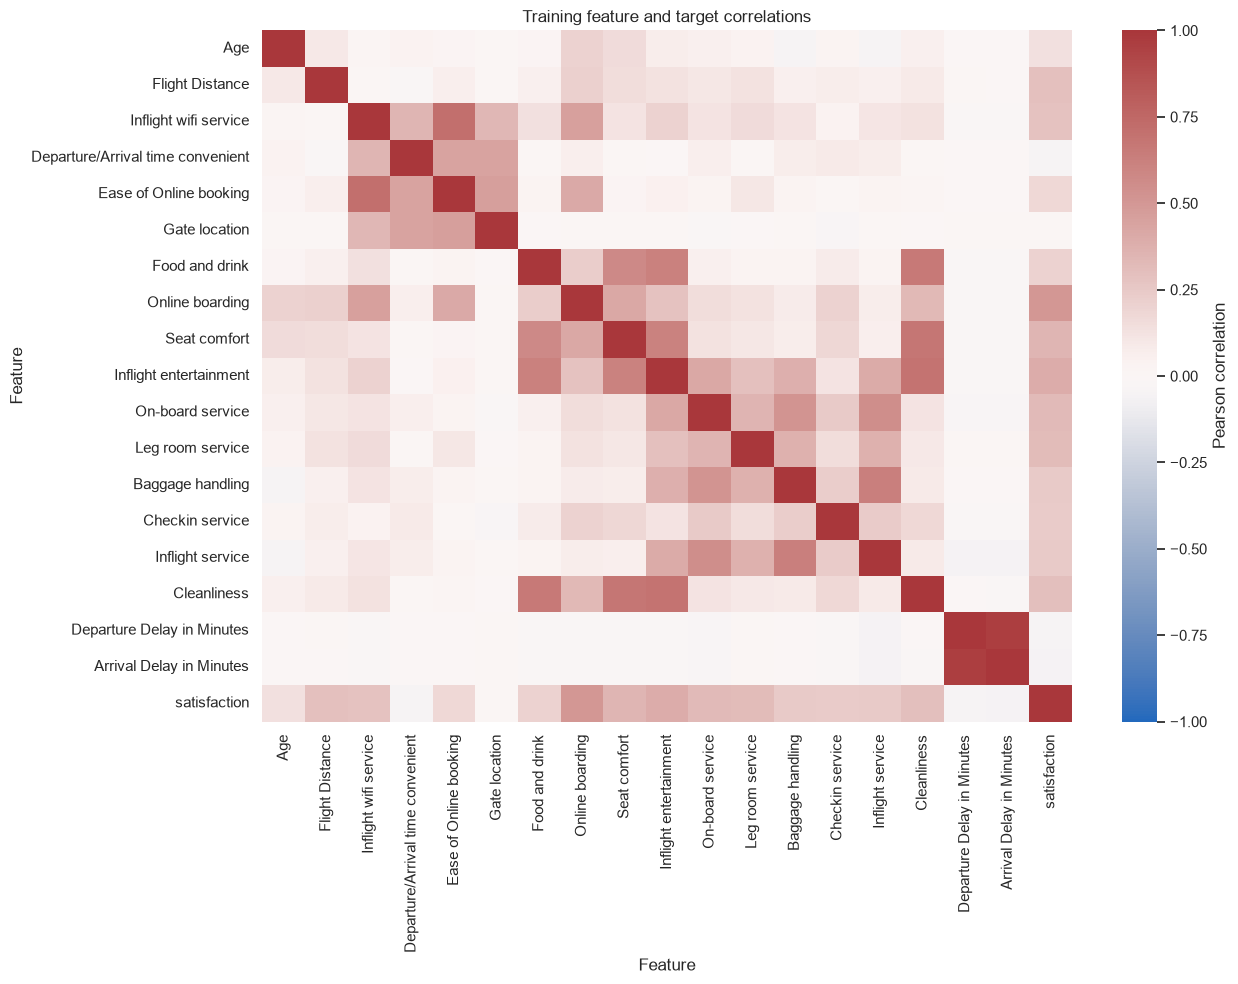

Online boarding           0.503970
Inflight entertainment    0.395947
Seat comfort              0.347396
On-board service          0.321167
Leg room service          0.314481
Cleanliness               0.303287
Flight Distance           0.296739
Inflight wifi service     0.286685
Name: satisfaction, dtype: float64

In [9]:
# correlation heatmap to find relationships between features
corr = data.select_dtypes(include="number").corr()
plt.figure(figsize=(13, 10))
sns.heatmap(corr, cmap="vlag", center=0, vmin=-1, vmax=1, cbar_kws={"label": "Pearson correlation"})
plt.title("Training feature and target correlations")
plt.xlabel("Feature")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()
display(corr["satisfaction"].drop("satisfaction").sort_values(key=abs, ascending=False).head(8))

Online boarding and several service ratings are associated with satisfaction. Arrival and departure delays are highly correlated. Correlated ratings may limit Naive Bayes because it assumes conditional independence.

The correlation between service ratings and satisfaction is the most useful finding here. Online boarding stands out as the strongest single predictor. The high correlation between arrival and departure delays also makes sense. If one is late, the other usually is too. We could drop one of them, but tree models handle correlated features fine.

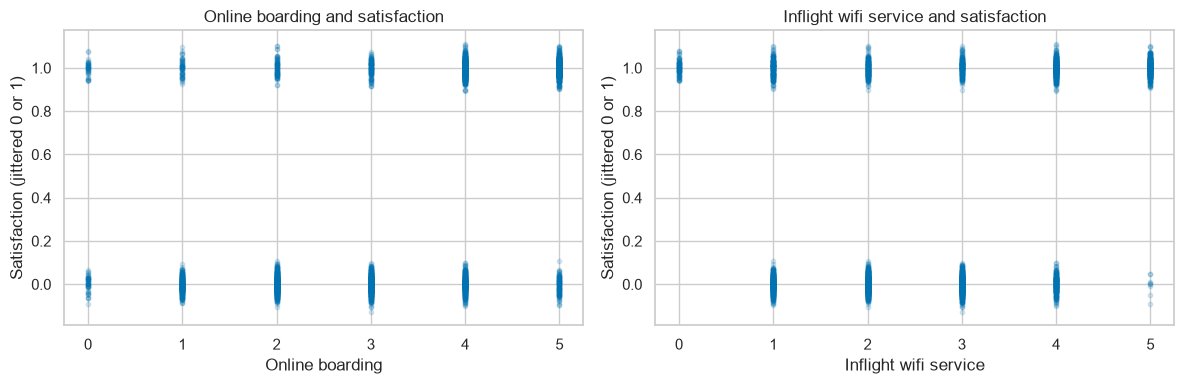

In [10]:
plot_df = data.sample(n=min(4000, len(data)), random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['Online boarding', 'Inflight wifi service']):
    values = plot_df["satisfaction"].to_numpy(dtype=float)
    values = values + np.random.default_rng(42).normal(0, 0.035, len(values))
    ax.scatter(plot_df[col], values, alpha=0.15, s=10)
    ax.set(title=col + " and satisfaction", xlabel=col, ylabel="Satisfaction (jittered 0 or 1)")
plt.tight_layout()
plt.show()

Higher service ratings tend to include more satisfied passengers, but the two classes still overlap. The points have a small vertical offset so repeated 0 and 1 values remain visible.

In [11]:
# IQR-based outlier detection across numeric features
q1 = x_train[num].quantile(0.25)
q3 = x_train[num].quantile(0.75)
iqr = q3 - q1
outside = (x_train[num] < q1 - 1.5 * iqr) | (x_train[num] > q3 + 1.5 * iqr)
display(outside.sum().sort_values(ascending=False).rename("IQR flags"))

Departure Delay in Minutes           11604
Arrival Delay in Minutes             11193
Checkin service                      10279
Flight Distance                       1886
Age                                      0
Inflight wifi service                    0
Food and drink                           0
Departure/Arrival time convenient        0
Ease of Online booking                   0
Gate location                            0
Inflight entertainment                   0
Seat comfort                             0
Online boarding                          0
On-board service                         0
Baggage handling                         0
Leg room service                         0
Cleanliness                              0
Inflight service                         0
Name: IQR flags, dtype: int64

The IQR rule flags long flights and long delays. These are possible flight experiences, so the rows are kept. Log transforms reduce their skew. Missing arrival delays are filled using the training median.

Same logic as the news dataset: these aren't data errors, they're just passengers who had very long flights or extreme delays. Removing them would bias the model against unusual but real scenarios.

## Feature engineering

`service_mean` averages twelve service ratings to summarize the overall experience. Departure-time convenience and gate location are excluded because they describe convenience rather than service quality. A tree can use this average to separate consistently good and poor service.

The `service_mean` feature is a neat trick. Instead of making the model figure out that "all ratings being high = satisfied", we give it that information directly. This is especially helpful for simpler models like logistic regression and Naive Bayes that can't easily combine multiple features on their own.

In [12]:
# feature engineering: service_mean and log transforms
service = ["Inflight wifi service", "Ease of Online booking", "Food and drink", "Online boarding",
           "Seat comfort", "Inflight entertainment", "On-board service", "Leg room service",
           "Baggage handling", "Checkin service", "Inflight service", "Cleanliness"]
def prepare(x):
    x = x.copy()
    x["service_mean"] = x[service].mean(axis=1)
    for col in ["Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"]:
        x[col] = np.log1p(x[col])
    return x

x_train = prepare(x_train)
x_test = prepare(x_test)

### Encoding and scaling

In [13]:
# set up preprocessing pipeline: impute + scale for numeric, encode for categorical
num = x_train.select_dtypes(include="number").columns.tolist()
cat = x_train.select_dtypes(include=["str", "object", "category"]).columns.tolist()
num_pipe = Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())])
cat_pipe = Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                     ("encode", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))])
prep = ColumnTransformer([("num", num_pipe, num), ("cat", cat_pipe, cat)], verbose_feature_names_out=False)

In [14]:
train_arr = prep.fit_transform(x_train)
test_arr = prep.transform(x_test)
names = prep.get_feature_names_out()
train = pd.DataFrame(train_arr, columns=names)
test = pd.DataFrame(test_arr, columns=names)
assert np.isfinite(train_arr).all() and np.isfinite(test_arr).all()
display(train.head())
print("Processed shapes:", train.shape, test.shape)

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,...,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,service_mean,Gender_Male,Customer Type_disloyal Customer,Type of Travel_Personal Travel,Class_Eco,Class_Eco Plus
0,0.502794,0.682420,0.202302,-0.039803,0.172981,0.016414,1.352437,0.556185,1.184892,0.481464,...,0.305805,-0.218315,-0.762485,-0.774941,0.899871,0.0,0.0,0.0,0.0,0.0
1,-0.290464,1.262861,0.202302,-0.039803,0.172981,0.799207,-0.151471,-0.185065,1.184892,-0.268817,...,0.305805,-0.218315,-0.762485,-0.774941,0.899871,1.0,1.0,0.0,0.0,0.0
2,1.758785,-0.429333,-0.551202,0.615219,-0.541985,-0.766378,1.352437,0.556185,1.184892,0.481464,...,0.305805,1.304785,1.932052,1.933324,0.547904,0.0,0.0,1.0,1.0,0.0
3,-0.885408,0.484361,1.709308,0.615219,0.887947,-1.549171,-0.151471,1.297435,-0.330704,-0.268817,...,0.305805,-0.218315,-0.762485,-0.774941,0.547904,1.0,1.0,0.0,1.0,0.0
4,0.568898,-0.108118,-1.304705,1.270240,-1.971917,-0.766378,0.600483,-2.408814,0.427094,0.481464,...,1.156807,0.543235,1.811762,1.622701,-0.390676,1.0,0.0,1.0,1.0,0.0


Processed shapes: (83123, 24) (20781, 24)


Numeric columns use median imputation and StandardScaler. Categories use the most frequent value and one-hot encoding. All fitted steps learn from the training set only.

Fitting the scaler and imputer on training data only is crucial. If we fit them on the whole dataset, information from the test set would leak into the preprocessing, and our evaluation metrics would be overly optimistic. This is one of the most common mistakes in ML projects.

## Saving the datasets

The processed CSVs contain model-ready values. The `_raw` files preserve the same split before imputation, encoding, and scaling for cross-validation.

In [15]:
# save processed features with target column for the classification notebook
train["satisfaction"] = y_train.to_numpy()
test["satisfaction"] = y_test.to_numpy()
train.to_csv("../processed_datasets/airline_train.csv", index=False)
test.to_csv("../processed_datasets/airline_test.csv", index=False)

In [16]:
raw_train = x_train.copy()
raw_test = x_test.copy()
raw_train["satisfaction"] = y_train
raw_test["satisfaction"] = y_test
raw_train.to_csv("../processed_datasets/airline_train_raw.csv", index=False)
raw_test.to_csv("../processed_datasets/airline_test_raw.csv", index=False)

In [17]:
split = pd.DataFrame({"source_row": list(x_train.index) + list(x_test.index),
                      "split": ["train"] * len(x_train) + ["test"] * len(x_test)})
split.to_csv("../processed_datasets/airline_split_rows.csv", index=False)
assert set(x_train.index).isdisjoint(x_test.index)
print("Saved processed data, unscaled companion data, and original row assignments.")

Saved processed data, unscaled companion data, and original row assignments.
